# Метод K блиайших соседей

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

RANDOM_SEED = 42

In [62]:
iris = load_iris() 
features = iris.data

data = pd.DataFrame(features, columns = iris.feature_names)
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [63]:
X = data.iloc[:, [0, 2]]
y = iris.target
X.shape, y.shape

((150, 2), (150,))

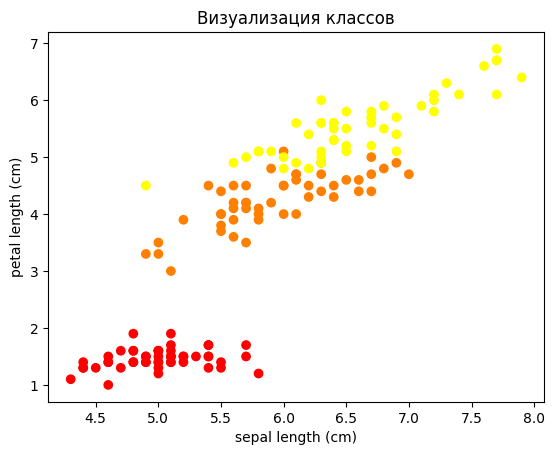

In [64]:
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='autumn')

plt.title("Визуализация классов")
plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.show()

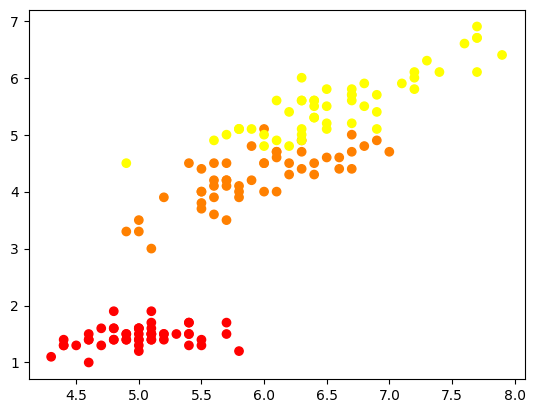

In [65]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='autumn')
plt.show()

In [66]:
from sklearn.neighbors import KNeighborsClassifier 

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_scaled, y)

y_pred = knn.predict(X_scaled)

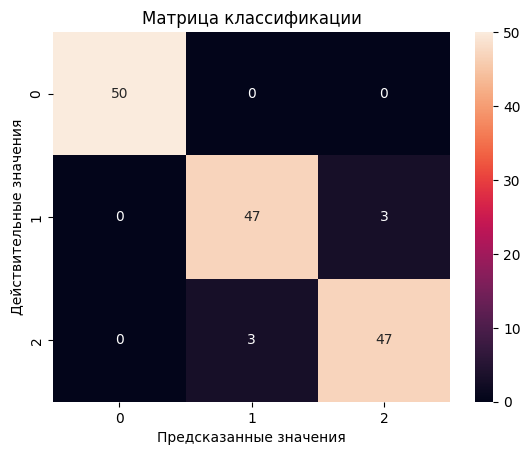

In [67]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

plt.title("Матрица классификации")
sns.heatmap(confusion_matrix(y, y_pred), annot=True, fmt ='d')
plt.ylabel('Действительные значения')
plt.xlabel('Предсказанные значения')
plt.show()

In [68]:
from sklearn.metrics import classification_report
print(classification_report(y_pred, y))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.94      0.94      0.94        50
           2       0.94      0.94      0.94        50

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150



c:\Users\vadve\VS_Projects\misis_ml_course_6sem\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


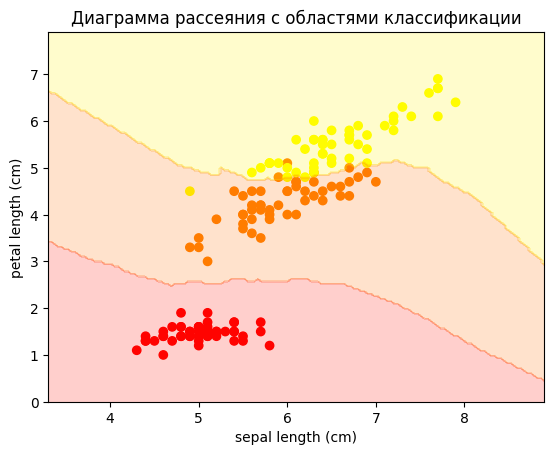

In [69]:
X0 = np.linspace(X.iloc[:, 0].min()-1,X.iloc[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X.iloc[:, 1].min()-1,X.iloc[:, 1].max()+1, X.shape[0])

X0_grid, X1_grid = np.meshgrid(X0, X1)

XX = np.array([X0_grid.ravel(), X1_grid.ravel()]).T
XX_scaled = scaler.transform(XX)
Z = knn.predict(XX_scaled).reshape(X0_grid.shape)

plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='autumn')
plt.contourf(X0_grid, X1_grid, Z, cmap='autumn', alpha=0.2)

plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.title("Диаграмма рассеяния с областями классификации")
plt.show()

c:\Users\vadve\VS_Projects\misis_ml_course_6sem\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


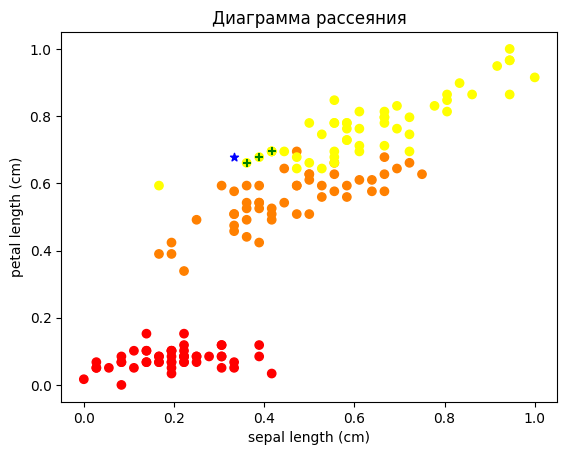

In [70]:
observation_new = [[5.5, 5]]
observation_new_scaled = scaler.transform(observation_new)
knn.predict(observation_new_scaled)
knn.predict_proba(observation_new_scaled)
distances, indices = knn.kneighbors(observation_new_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='autumn')

plt.scatter(observation_new_scaled[0][0], observation_new_scaled[0][1], marker='*', color='b')

plt.scatter(X_scaled[indices[0]][0][0], X_scaled[indices[0]][0][1], marker='+', color='g')
plt.scatter(X_scaled[indices[0]][1][0], X_scaled[indices[0]][1][1], marker='+', color='g')
plt.scatter(X_scaled[indices[0]][2][0], X_scaled[indices[0]][2][1], marker='+', color='g')

plt.title("Диаграмма рассеяния")
plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.show()

## Задания для самостоятельного выполнения

#### 1. Постройте последний график методических указаний в исходном пространстве признаков.

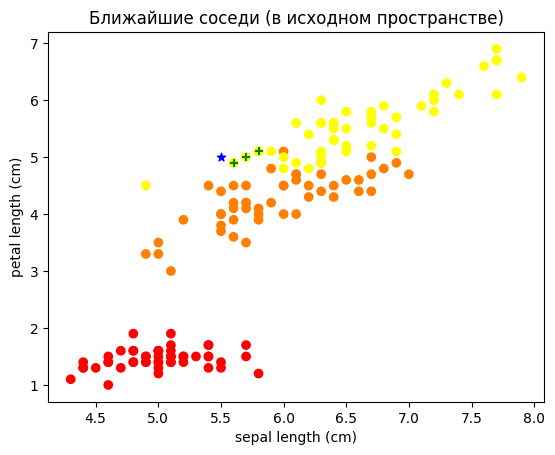

In [71]:
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='autumn')

plt.scatter(observation_new[0][0], observation_new[0][1], marker='*', color='blue')

neighbors = X.iloc[indices[0]]

plt.scatter(neighbors.iloc[:, 0], neighbors.iloc[:, 1], marker='+', color='green')

plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.title("Ближайшие соседи (в исходном пространстве)")
plt.show()

#### 2. Попробуйте обучить модель с другим значением k. Визуализируйте области классификации и сравните эффективности модели.

In [72]:
from sklearn.metrics import accuracy_score

k_values = [1, 3, 5, 10, 101]

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_scaled, y)
    
    y_pred = knn.predict(X_scaled)
    acc = accuracy_score(y, y_pred)
    
    print(f"k={k}, accuracy={acc:.4f}")
    
# маленькое k => переобучение

k=1, accuracy=0.9933
k=3, accuracy=0.9600
k=5, accuracy=0.9533
k=10, accuracy=0.9400
k=101, accuracy=0.6400


#### 3. Подвигайте новое наблюдение в последнем пункте методических указаний. Сдвиньте его за пределы области определения выборки. Как меняется нормализованное значение?

Исходная точка: [[10, 10]]
Scaled: [[1.58333333 1.52542373]]
Комментарий: при выходе за максимум нормализованные значения становятся > 1, а при выходе за минимум — < 0.


C:\Users\vadve\AppData\Local\Temp\ipykernel_24420\4135725886.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


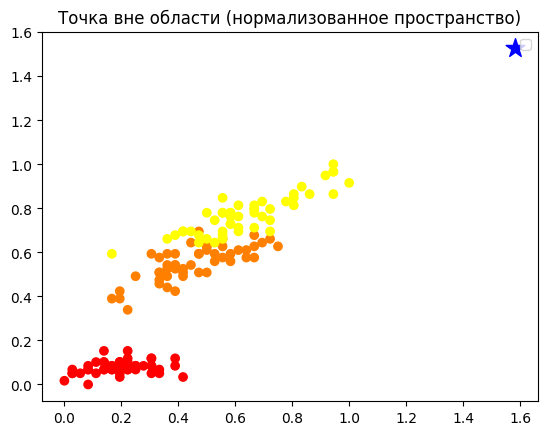

In [73]:
scaler_2d = MinMaxScaler()
X_scaled_2d = scaler_2d.fit_transform(X)

observation_new = [[10, 10]]  # вне диапазона
observation_new_df = pd.DataFrame(observation_new, columns=X.columns)
observation_new_scaled = scaler_2d.transform(observation_new_df)

print("Исходная точка:", observation_new)
print("Scaled:", observation_new_scaled)
print("Комментарий: при выходе за максимум нормализованные значения становятся > 1, а при выходе за минимум — < 0.")

plt.scatter(X_scaled_2d[:, 0], X_scaled_2d[:, 1], c=y, cmap='autumn')

# новая точка
plt.scatter(observation_new_scaled[0][0], observation_new_scaled[0][1],
            marker='*', color='blue', s=200)

plt.title("Точка вне области (нормализованное пространство)")
plt.legend()
plt.show()

#### 4. Поэкспериментируйте с разными метриками расстояния. Визуализируйте ближайших соседей нового объекта при разных метриках расстояния.

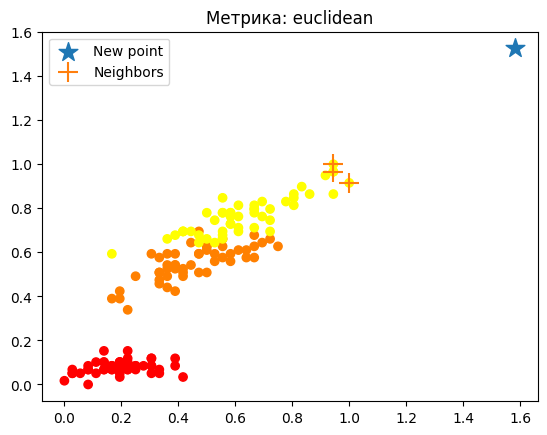

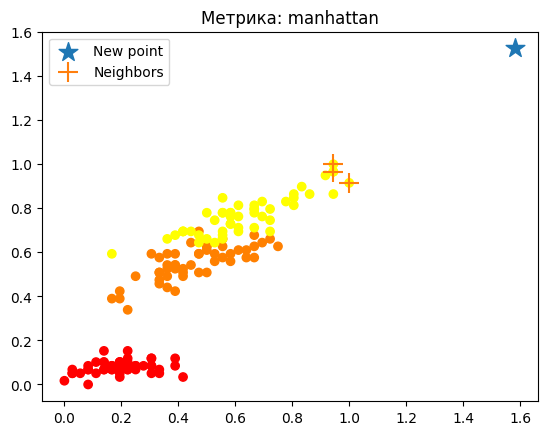

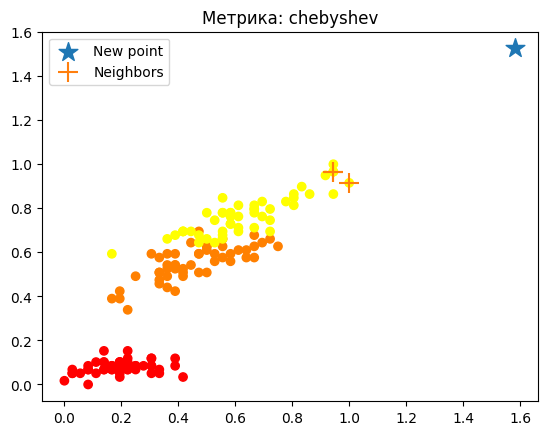

In [74]:
metrics = ['euclidean', 'manhattan', 'chebyshev']

for metric in metrics:
    knn = KNeighborsClassifier(n_neighbors=3, metric=metric)
    knn.fit(X_scaled, y)
    
    distances, indices = knn.kneighbors(observation_new_scaled)

    plt.figure()
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='autumn')
    
    plt.scatter(observation_new_scaled[0][0], observation_new_scaled[0][1],
                marker='*', s=200, label='New point')

    plt.scatter(X_scaled[indices[0]][:, 0],
                X_scaled[indices[0]][:, 1],
                marker='+', s=200, label='Neighbors')
    
    plt.title(f"Метрика: {metric}")
    plt.legend()
    plt.show()

#### 5. Обучите модель на полном датасете. Сравните ее эффективность с описанной в методических указаниях. Попробуйте разные значения k.

In [75]:
X_full = iris.data
y_full = iris.target

scaler = MinMaxScaler()
X_full_scaled = scaler.fit_transform(X_full)

k_values = [1, 3, 5, 10, 101]

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_full_scaled, y_full)
    
    acc = accuracy_score(y_full, knn.predict(X_full_scaled))
    print(f"k={k}, accuracy={acc:.4f}")

k=1, accuracy=1.0000
k=3, accuracy=0.9667
k=5, accuracy=0.9600
k=10, accuracy=0.9667
k=101, accuracy=0.6733


#### 6. Попробуйте в модели на полном датасете взвешенный алгоритм (аргумент weights объекта KNeighborsClassifier). Сравние его точность с равномерным вариантом.

In [76]:
knn_uniform = KNeighborsClassifier(n_neighbors=3, weights='uniform')
knn_distance = KNeighborsClassifier(n_neighbors=3, weights='distance')

knn_uniform.fit(X_full_scaled, y_full)
knn_distance.fit(X_full_scaled, y_full)

acc_uniform = accuracy_score(y_full, knn_uniform.predict(X_full_scaled))
acc_distance = accuracy_score(y_full, knn_distance.predict(X_full_scaled))

print("Uniform:", acc_uniform)
print("Distance:", acc_distance)

Uniform: 0.9666666666666667
Distance: 1.0


#### 7. Постройте график точности (accuracy) модели в зависимости от значения k. Сделайте вывод.

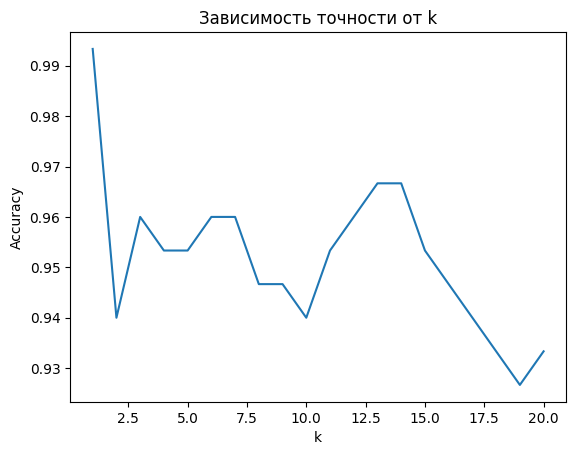

In [77]:
k_range = range(1, 21)
accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_scaled, y)
    acc = accuracy_score(y, knn.predict(X_scaled))
    accuracies.append(acc)

plt.plot(k_range, accuracies)
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Зависимость точности от k")
plt.show()

#### 8. Выберите датасет и постройте регрессию при помощи метода ближайших соседей.

R2 (test): 0.206
MSE (test): 4209.321


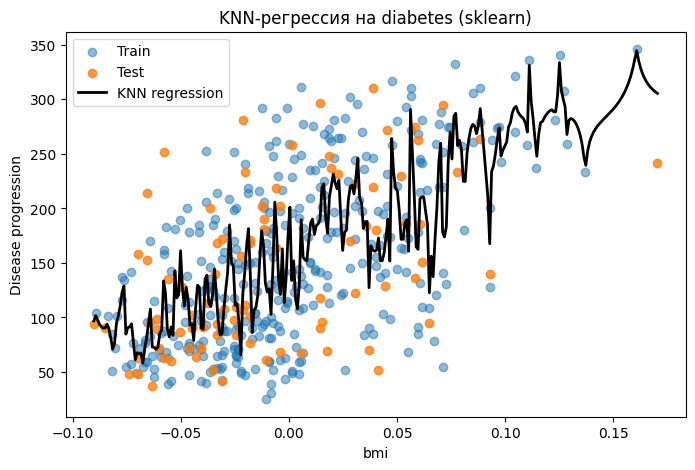

In [78]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

diabetes = load_diabetes()
X_reg = diabetes.data[:, [2]]
y_reg = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_SEED
)

scaler_reg = MinMaxScaler()
X_train_scaled = scaler_reg.fit_transform(X_train)
X_test_scaled = scaler_reg.transform(X_test)

knn_reg = KNeighborsRegressor(n_neighbors=7, weights='distance')
knn_reg.fit(X_train_scaled, y_train)
y_test_pred = knn_reg.predict(X_test_scaled)

print(f"R2 (test): {r2_score(y_test, y_test_pred):.3f}")
print(f"MSE (test): {mean_squared_error(y_test, y_test_pred):.3f}")

x_line = np.linspace(X_reg.min(), X_reg.max(), 300).reshape(-1, 1)
x_line_scaled = scaler_reg.transform(x_line)
y_line = knn_reg.predict(x_line_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, alpha=0.5, label='Train')
plt.scatter(X_test, y_test, alpha=0.8, label='Test')
plt.plot(x_line, y_line, color='black', linewidth=2, label='KNN regression')
plt.xlabel(diabetes.feature_names[2])
plt.ylabel('Disease progression')
plt.title('KNN-регрессия на diabetes (sklearn)')
plt.legend()
plt.show()